In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import joblib

In [4]:
# Load dataset
df = pd.read_csv("baringo-data.csv", parse_dates=['time'])


### Implement clustering of regions in Baringo

Considered these features
- Precipitation - Higher rainfall areas are more prone to floods.
- Humidity - Humid regions may retain more moisture, affecting drought and flood likelihood.
- Dew Point - Indicates moisture content in the air, influencing weather stability.
- Temperature - Helps distinguish between hot, dry regions (prone to drought) and cooler, wet areas.
- Wind Speed - Impacts evaporation and the movement of storm systems.
- Pressure - Changes in atmospheric pressure can signal upcoming weather conditions.

Grouped areas with similar weather patterns into clusters

In [5]:
# Select relevant features for clustering
features = ['temperature', 'humidity', 'dew_point', 'wind_speed', 'pressure', 'precipitation']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

In [6]:
# Apply K-Means clustering (Divide into  4 regions)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['region_id'] = kmeans.fit_predict(scaled_data)

In [7]:
# Save the model
joblib.dump(kmeans, "models/kmeans_model.pkl")

['models/kmeans_model.pkl']

In [8]:
# View sample clustered data
df[['time', 'region_id', 'temperature', 'humidity', 'precipitation']].head()

,time,region_id,temperature,humidity,precipitation
0,2010-01-01,3,18.0,85.0,23.0
1,2010-01-02,3,18.0,89.0,28.8
2,2010-01-03,0,18.0,82.0,2.5
3,2010-01-04,2,18.0,76.0,1.7
4,2010-01-05,2,19.0,69.0,1.3


In [9]:
# Save clustered data
df.to_csv("baringo_clustered_data.csv", index=False)

In [10]:
df['region_id'].value_counts()

region_id
2    1419
0    1338
1     883
3     378
Name: count, dtype: int64

### Visualize the regions' weather conditions

Here is how the regions were clustered:
- Region 0: **Hot and Humid Zone** – Characterized by low precipitation, high humidity, high dew point, weak winds, and high temperatures. This region likely experiences warm and muggy conditions.

- Region 1: **Cool and Windy Zone** – Defined by low precipitation, low humidity, low dew point, strong winds, and low temperatures. This area is likely dry and breezy with cool conditions.
- Region 2: **Warm and Moderate Zone** – Exhibits low precipitation, moderate humidity, moderate dew point, moderate winds, and high temperatures. This suggests a balanced but warm climate with occasional dry spells.
- Region 3: **Rain-Prone Cool Zone** – Has high precipitation, high humidity, high dew point, weak winds, and low temperatures, making it the wettest and coolest region, likely experiencing frequent rainfall.


From this you can not the following assumptions
- Region 3 → Most flood-prone (high precipitation, high humidity, high dew point).
- Region 1 → Most drought-prone (low precipitation, low humidity, strong winds).
- Region 2 → Moderate drought risk, but not as extreme as Region 1.
- Region 0 → Moderate flood risk, but dependent on additional precipitation events.

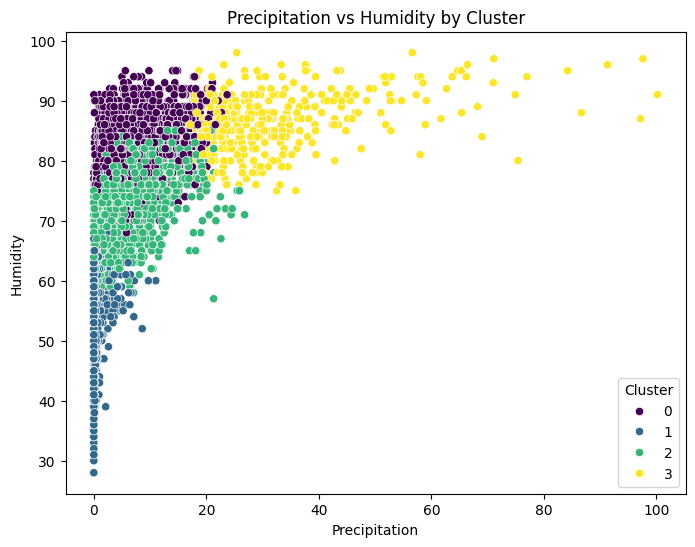

In [11]:
# 1. Scatter plot: Precipitation vs Humidity colored by Cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['precipitation'], y=df['humidity'], hue=df['region_id'], palette='viridis')
plt.title("Precipitation vs Humidity by Cluster")
plt.xlabel("Precipitation")
plt.ylabel("Humidity")
plt.legend(title="Cluster")
plt.show()

/tmp/ipykernel_14777/1354954694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['region_id'], y=df[feature], palette='Set2')
/tmp/ipykernel_14777/1354954694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['region_id'], y=df[feature], palette='Set2')
/tmp/ipykernel_14777/1354954694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['region_id'], y=df[feature], palette='Set2')
/tmp/ipykernel_14777/1354954694.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

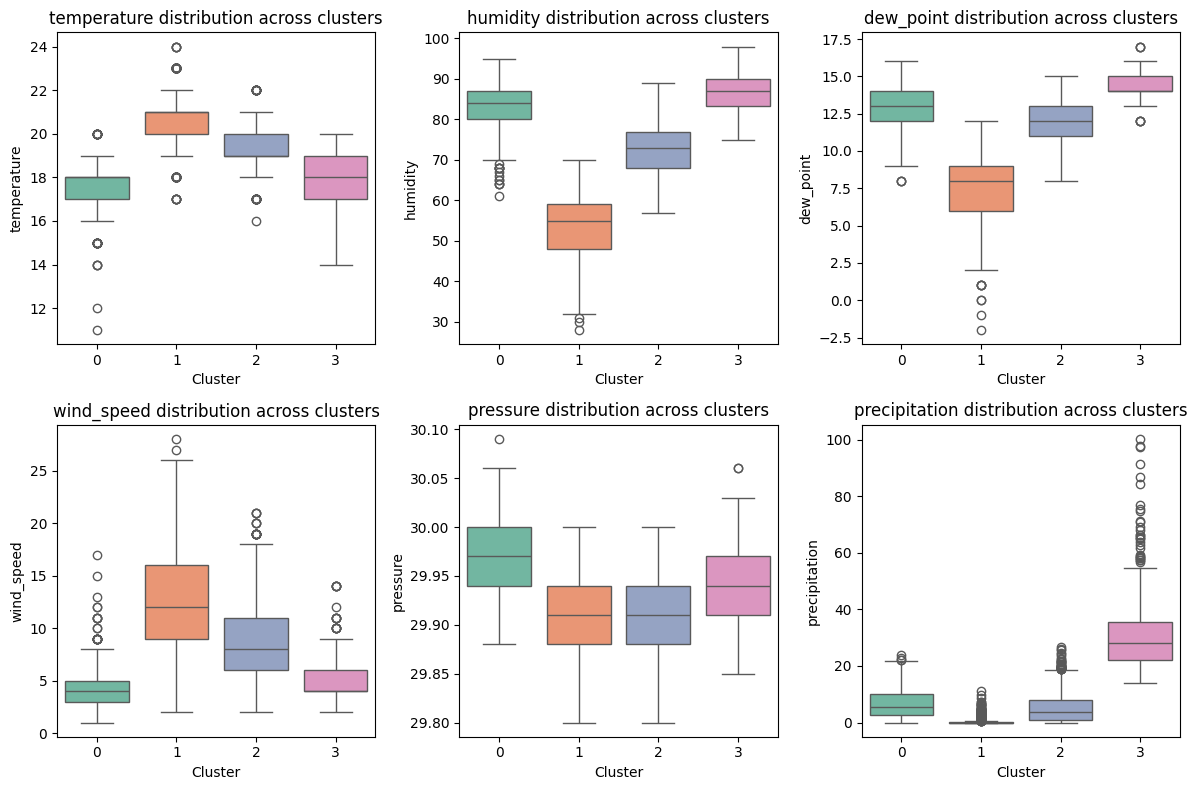

In [12]:
# 2. Box plots for each feature per cluster
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df['region_id'], y=df[feature], palette='Set2')
    plt.title(f"{feature} distribution across clusters")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

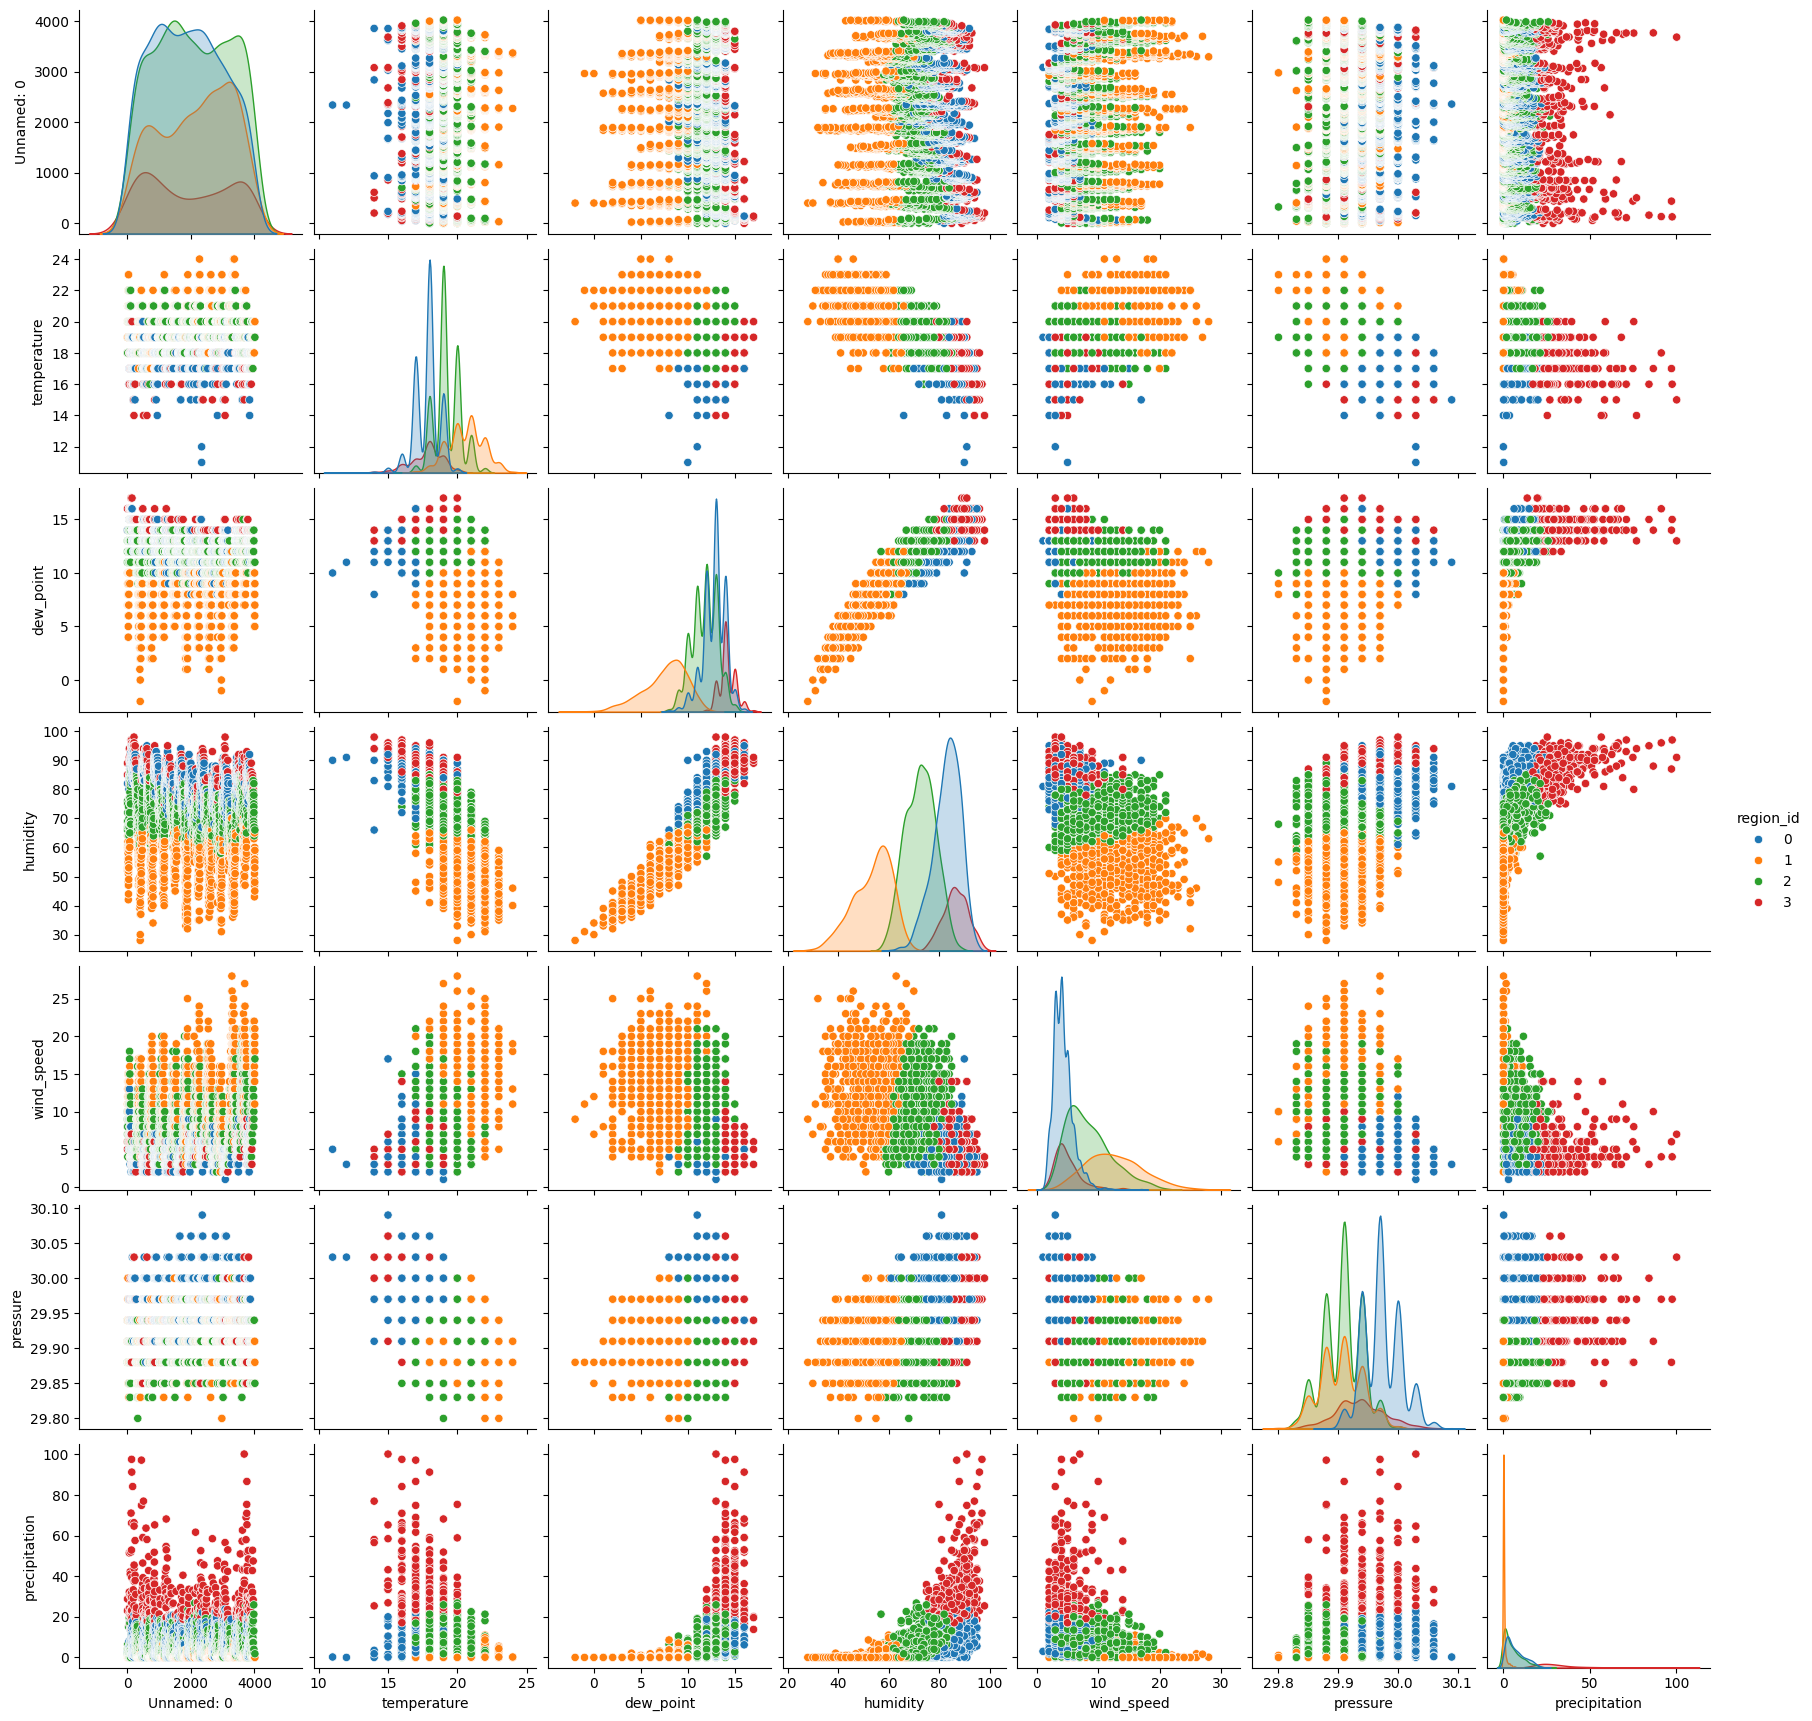

In [13]:
# 3. Pair plot to show feature relationships by cluster
sns.pairplot(df, hue="region_id", palette="tab10", diag_kind="kde", height=2.5)
plt.show()

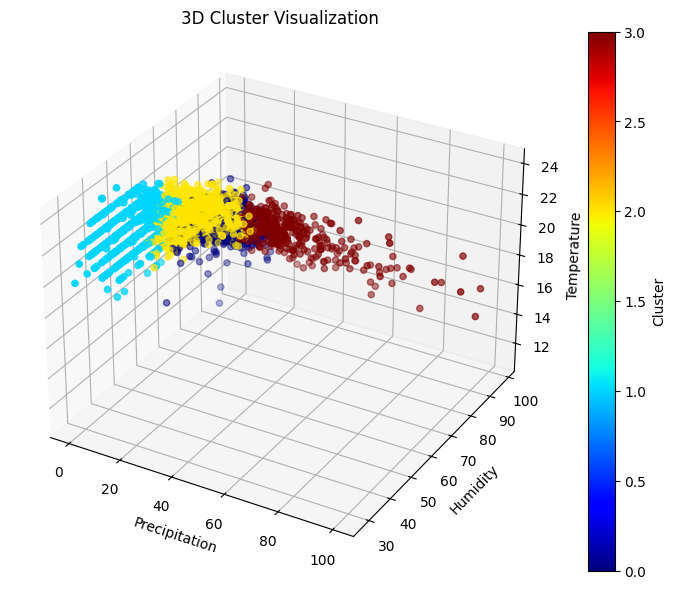

In [14]:
# 4. 3D Scatter Plot: Precipitation, Humidity, and Temperature
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['precipitation'], df['humidity'], df['temperature'], c=df['region_id'], cmap='jet')
ax.set_xlabel('Precipitation')
ax.set_ylabel('Humidity')
ax.set_zlabel('Temperature')
plt.title("3D Cluster Visualization")
plt.colorbar(sc, label='Cluster')
plt.show()

In [15]:
# 5. Cluster Centroids Summary
centroids = df.groupby("region_id")[features].mean()
print("Cluster Centroids (Average Weather Conditions):")
print(centroids)

Cluster Centroids (Average Weather Conditions):
           temperature   humidity  dew_point  wind_speed   pressure  \
region_id                                                             
0            17.795217  82.996263  12.790732    4.236921  29.973363   
1            20.584371  53.574179   7.579841   12.590034  29.904994   
2            19.269908  72.495419  11.785060    8.428471  29.907019   
3            17.777778  86.518519  14.185185    4.912698  29.936746   

           precipitation  
region_id                 
0               6.819507  
1               0.444960  
2               5.288020  
3              31.902646  
